# Bước 2: Feature Engineering - 14 đặc trưng hành vi trên 5 nhóm

Notebook này xây dựng **20 đặc trưng hành vi ứng viên** trên 5 nhóm thương mại từ dữ liệu giao dịch đã làm sạch, áp dụng bộ lọc tương quan Pearson tham lam (|r| > 0,85) để giữ lại **14 đặc trưng**, sau đó tiền xử lý theo chuỗi QuantileTransformer, StandardScaler và cắt ngưỡng ±3σ.

Ma trận đặc trưng đã chuẩn hoá được đưa vào pipeline phân cụm hai giai đoạn:
1. **Giai đoạn 1**: Bộ lọc B2B dựa trên quy tắc (SKU_HHI > 0,5 trên đặc trưng thô), cô lập 179 tài khoản bán buôn
2. **Giai đoạn 2**: K-Means++ k=4 trên nhóm retail (3.741 khách hàng)

## Mục tiêu

1. Xây dựng 20 đặc trưng ứng viên trên 5 nhóm hành vi
2. Áp dụng bộ lọc tương quan Pearson tham lam (|r| > 0,85), giữ lại 14 đặc trưng
3. Tiền xử lý: QuantileTransformer (phân phối chuẩn, 500 phân vị), StandardScaler, cắt ±3σ
4. Xác định khách hàng B2B qua quy tắc SKU_HHI > 0,5 trên đặc trưng thô, tách nhóm retail
5. Lưu đặc trưng đã chuẩn hoá cho toàn bộ dân số và nhóm retail

**Tại sao vượt qua RFM?** Ba chiều RFM (Recency, Frequency, Monetary) không phân biệt được:
- Khách hàng hoàn trả nhiều (tỉ lệ huỷ hoá đơn 25%) so với người mua lặp lại thực sự
- Khách hàng mua theo mùa so với khách hàng có tần suất đều đặn quanh năm

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

from clustering_library import FeatureEngineer
from notebook_io import wpath, rpath   # manual runs write to data/_sandbox, never canonical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Tải dữ liệu đã làm sạch

In [2]:
# Read 01's cleaned data from the sandbox if a manual run produced it, else canonical.
data_path     = rpath('processed/cleaned_uk_data.csv')
raw_data_path = '../data/raw/online_retail.csv'

fe = FeatureEngineer(data_path, raw_data_path=raw_data_path)
df = fe.load_data()
print(f"Dataset: {df.shape[0]:,} transactions | {df['CustomerID'].nunique():,} customers")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head()

Dataset: 354,321 transactions | 3,920 customers
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,HourOfDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2,8


## 2. Các nhóm đặc trưng - 20 ứng viên

20 đặc trưng trải trên 5 nhóm. Các đặc trưng đánh dấu `✗` bị loại bởi bộ lọc tương quan Pearson (|r| > 0,85 trong model space).

| Nhóm | Đặc trưng | Công thức | Giữ lại |
|------|-----------|-----------|:-------:|
| **1 Nhịp mua hàng** | `Recency` | Ngày kể từ lần mua cuối | ✓ |
| | `InterPurchaseCV` | σ/μ khoảng cách mua hàng | ✓ |
| | `ActiveSpanDays`* | (ngày cuối − ngày đầu mua).days | ✗ |
| | `MonthlyOrderRate` | Số hoá đơn / (active span tính theo tháng) | ✓ |
| **2 Hình dạng chi tiêu** | `AOV` | Tổng chi tiêu / số hoá đơn | ✓ |
| | `SpendGini`* | Hệ số Gini của chi tiêu theo hoá đơn | ✗ |
| | `PriceCV` | σ/μ của UnitPrice | ✓ |
| | `MaxSpendShare`* | Hoá đơn lớn nhất / tổng chi tiêu | ✗ |
| | `SpendAcceleration` | Độ dốc OLS của tích luỹ chi tiêu | ✓ |
| **3 Hành vi giỏ hàng** | `RepeatSKUFraction` | SKU mua >1 lần / tổng SKU | ✓ |
| | `BasketSizeCV` | CV(số SKU phân biệt mỗi giỏ) | ✓ |
| | `MedianBasketQty` | Trung vị số lượng đơn hàng | ✓ |
| | `NewSKURate`* | Tỉ lệ SKU mới mỗi lần mua (theo thứ tự thời gian) | ✗ |
| **4 Khối lượng & Số lượng lớn** | `BulkLineRate` | Tỉ lệ dòng có Qty >= 12 | ✓ |
| | `QuantityCV` | CV(Quantity) mỗi dòng | ✓ |
| | `SKU_HHI` | Σ(spend_i/total)² - chỉ số tập trung doanh thu | ✓ |
| | `BurstIndex`* | Hoá đơn ngày bận nhất / tổng hoá đơn | ✗ |
| **5 Vòng đời khách hàng** | `ReturnRate` | Hoá đơn C-prefix / tổng hoá đơn | ✓ |
| | `ReturnValueRate`* | Giá trị huỷ / tổng giá trị thô | ✗ |
| | `QuarterConcentration` | Chi tiêu quý lớn nhất / tổng chi tiêu | ✓ |

**Kết quả: 20 ứng viên, giữ lại 14** (loại 6: `ActiveSpanDays`, `SpendGini`, `MaxSpendShare`, `NewSKURate`, `BurstIndex`, `ReturnValueRate`)

## 3. Tính toán đặc trưng và áp dụng bộ lọc tương quan

In [ ]:
# Compute all 20 candidates and apply greedy Pearson correlation filter (|r| > 0.85)
customer_features = fe.create_customer_features()
customer_features.head()

,CustomerID,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
0,12346,326,0.000000,1.000000,77183.600000,0.000000,0.000000,0.000000,1.000000,0.000000,74215.0,1.000000,0.5000,0.000000,1.000000
1,12747,2,0.481030,0.901639,381.455455,0.759477,0.452381,0.341990,0.485437,0.795643,108.0,0.155133,0.0000,0.080691,0.508311
2,12748,1,2.188519,16.854839,161.338421,5.297178,0.561086,1.195062,0.114472,3.236208,43.0,0.003864,0.0625,1.780151,0.540647
3,12749,4,0.984354,0.717703,818.176000,0.948402,0.231250,0.746489,0.266332,1.053320,227.0,0.009578,0.3750,-0.028860,0.463502
4,12820,3,1.160315,0.371517,235.585000,0.694878,0.072727,0.338418,0.576271,0.644220,181.5,0.021868,0.0000,0.054495,0.588015


In [4]:
print(f"Candidates computed : {len(fe.CANDIDATES)}")
print(f"Features retained   : {len(fe.feature_customer)}")
print(f"Customers           : {customer_features.shape[0]:,}")
print(f"\nRetained features ({len(fe.feature_customer)}):")
for i, f in enumerate(fe.feature_customer, 1):
    print(f"  {i:2d}. {f}")

customer_features.set_index('CustomerID').describe().round(3)

Candidates computed : 20
Features retained   : 14
Customers           : 3,920

Retained features (14):
   1. Recency
   2. InterPurchaseCV
   3. MonthlyOrderRate
   4. AOV
   5. PriceCV
   6. RepeatSKUFraction
   7. BasketSizeCV
   8. BulkLineRate
   9. QuantityCV
  10. MedianBasketQty
  11. SKU_HHI
  12. ReturnRate
  13. SpendAcceleration
  14. QuarterConcentration


,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
count,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000,3920.000
mean,92.208,0.369,1.038,393.328,0.916,0.141,0.352,0.400,0.965,231.938,0.111,0.103,0.047,0.746
std,99.534,0.480,0.907,1869.971,0.576,0.192,0.364,0.294,0.546,1372.829,0.182,0.165,0.316,0.252
min,1.000,0.000,0.164,3.450,0.000,0.000,0.000,0.000,0.000,1.000,0.003,0.000,-0.822,0.253
25%,18.000,0.000,0.607,174.397,0.709,0.000,0.000,0.136,0.645,84.000,0.025,0.000,0.000,0.516
50%,51.000,0.000,1.000,281.618,0.865,0.059,0.290,0.380,0.860,146.000,0.050,0.000,0.000,0.755
75%,143.000,0.739,1.000,409.693,1.017,0.224,0.604,0.600,1.182,248.000,0.107,0.200,0.000,1.000
max,374.000,3.151,34.000,84236.250,14.518,1.000,2.026,1.000,9.253,74215.000,1.000,0.800,3.000,1.000


## 4. Tiền xử lý: QuantileTransformer, StandardScaler, ±3σ clip

**QuantileTransformer(output_distribution='normal', n_quantiles=500):**
- Ánh xạ bất kỳ phân phối đơn điệu nào về N(0,1) qua hàm phân vị thực nghiệm
- Không giả định tham số về phân phối đầu vào
- Nén các ngoại lệ cực đoan vào phần đuôi của N(0,1) thay vì phóng đại chúng
- Fit trên 3.920 khách hàng, lưu vào `quantile_transformer.pkl`

**StandardScaler:** Căn giữa lại đầu ra của QuantileTransformer về μ=0, σ=1 chính xác.

**Cắt ngưỡng ±3σ (sau chuẩn hoá):**
- Tài khoản B2B có z-scores `SKU_HHI` khoảng 4, làm méo centroid của nhóm retail
- Cắt tại ±3σ giới hạn ảnh hưởng mà không loại bỏ các giá trị đó

In [5]:
_ = fe.transform_features()          # QuantileTransformer(normal, 500 quantiles)
df_scaled = fe.scale_features()      # StandardScaler → ±3σ clip (V5 override)

# Ensure CustomerID is the index for downstream .loc[] lookups
if 'CustomerID' in df_scaled.columns:
    df_scaled = df_scaled.set_index('CustomerID')

print(f"Scaled features shape: {df_scaled.shape}")
print(f"Index name           : {df_scaled.index.name}")
print(f"Value range after clip: [{df_scaled.values.min():.2f}, {df_scaled.values.max():.2f}]")
df_scaled.head()

Scaled features shape: (3920, 14)
Index name           : CustomerID
Value range after clip: [-1.73, 1.93]


,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,RepeatSKUFraction,BasketSizeCV,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,SpendAcceleration,QuarterConcentration
CustomerID,,,,,,,,,,,,,,
12346,0.877983,-0.530921,0.136925,1.732051,-1.732051,-0.822169,-0.923725,1.375211,-1.500000,1.500000,1.500000,1.118883,-0.030675,0.781046
12747,-0.847101,0.522824,-0.162346,0.321059,-0.181351,0.759908,0.398952,0.078759,-0.040204,-0.186333,0.367973,-0.518984,0.712658,-0.627314
12748,-1.732051,1.009889,1.732051,-0.455417,1.366671,0.829909,0.852455,-0.200760,1.048725,-0.665083,-1.330426,0.800681,1.586956,-0.583028
12749,-0.651966,0.661711,-0.287661,0.945986,0.214517,0.579426,0.627462,-0.079747,0.201618,0.275542,-0.762511,1.015106,-0.756975,-0.672667
12820,-0.740035,0.717881,-0.773731,-0.125903,-0.299437,0.429761,0.397823,0.154809,-0.234525,0.125342,-0.359348,-0.518984,0.681440,-0.543121


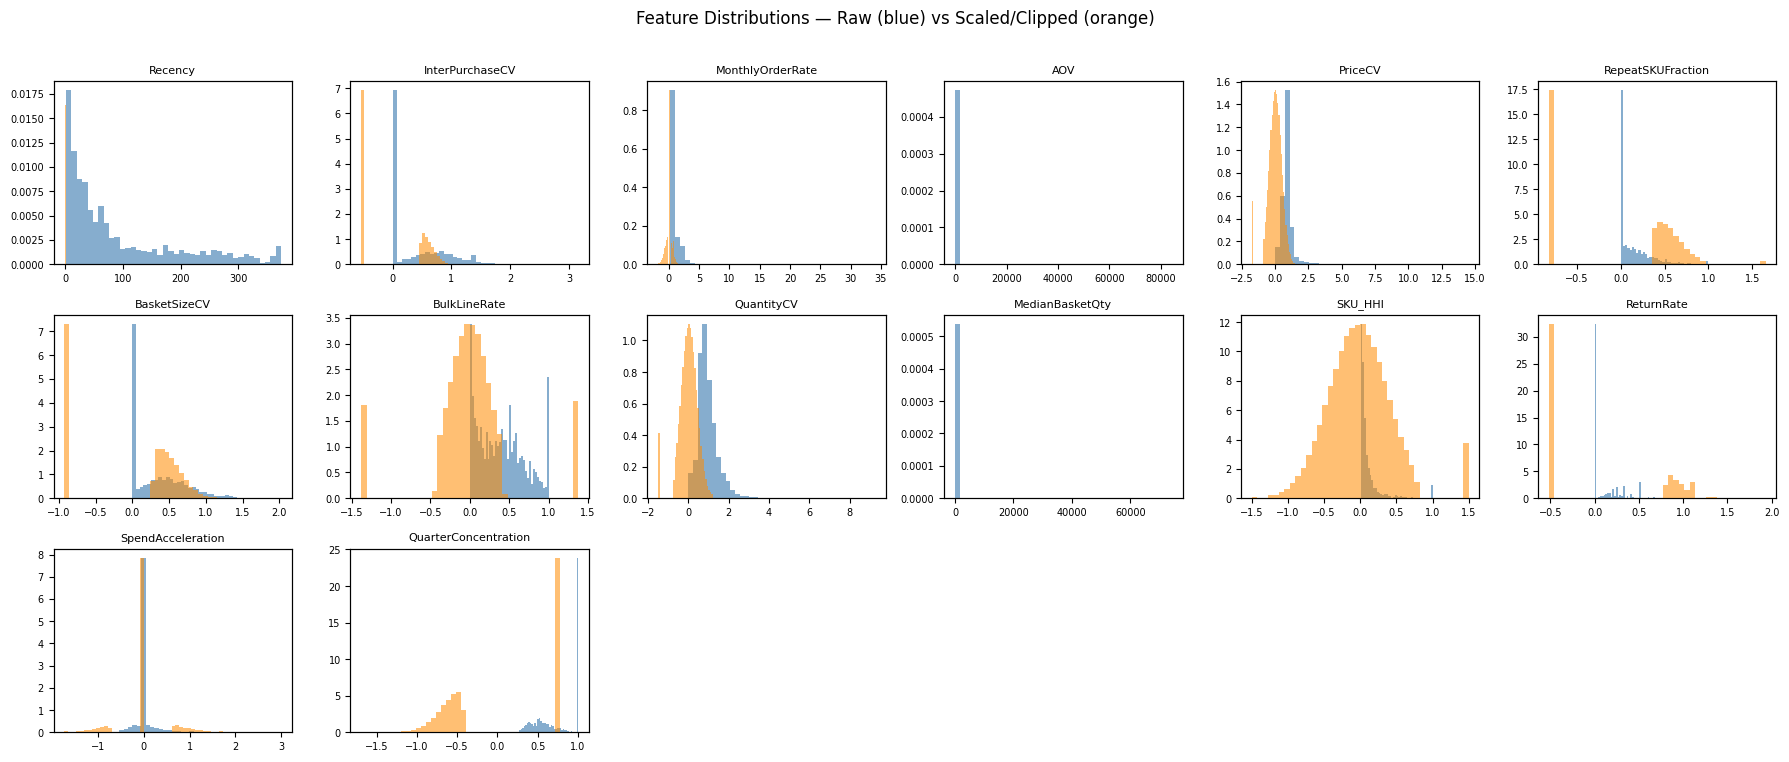

Max |z| after clip: 1.9319325437073487


In [7]:
# Feature distributions: raw vs scaled
feat_cols = fe.feature_customer
n = len(feat_cols)
ncols = 6
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.5))
axes = axes.flatten()

raw_df = customer_features.set_index('CustomerID')[feat_cols]

for i, col in enumerate(feat_cols):
    ax = axes[i]
    ax.hist(raw_df[col], bins=40, color='steelblue', alpha=0.65, label='raw', density=True)
    ax2 = ax.twinx()
    ax2.hist(df_scaled[col], bins=40, color='darkorange', alpha=0.55, label='scaled', density=True)
    ax2.set_yticks([])
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions — Raw (blue) vs Scaled/Clipped (orange)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../figures/02_features/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("Max |z| after clip:", df_scaled.abs().max().max())

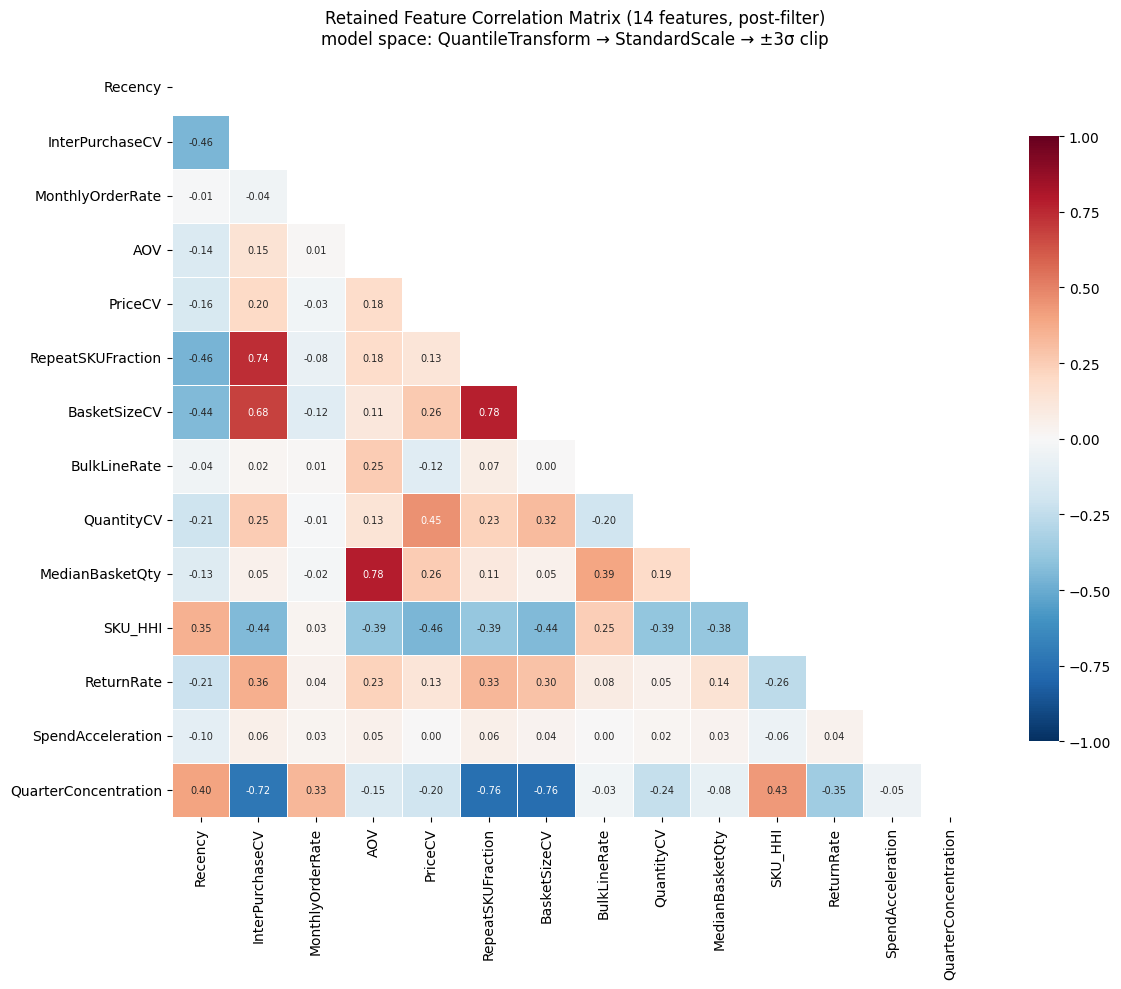

Max off-diagonal |r| in model space (post-filter): 0.781  (filter threshold was 0.85)


In [8]:
# Correlation matrix of retained features in the MODEL SPACE
# (QuantileTransform → StandardScale → ±3σ clip) — the same space the greedy
# Pearson filter ran in.  Raw-space correlations are NOT comparable to the 0.85
# threshold and will over-state collinearity for heavy-tailed features.
corr = df_scaled.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 7}
)
ax.set_title(
    "Retained Feature Correlation Matrix (14 features, post-filter)\n"
    "model space: QuantileTransform → StandardScale → ±3σ clip",
    fontsize=12, pad=12,
)
plt.tight_layout()
plt.savefig('../figures/02_features/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

max_offdiag = corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max()
print(f"Max off-diagonal |r| in model space (post-filter): {max_offdiag:.3f}  (filter threshold was 0.85)")
assert max_offdiag <= 0.85, (
    f"Filter invariant violated: max |r| = {max_offdiag:.3f} > 0.85. "
    "Check _filter_by_correlation in features.py."
)

## 5. Xác định khách hàng B2B

Tài khoản giống wholesale là khách hàng doanh nghiệp đặt hàng số lượng lớn thường xuyên cho một dòng sản phẩm duy nhất. Họ gây nhiễu cho quá trình phân cụm retail vì hai lý do:

1. **Giá trị đặc trưng cực đoan**: SKU_HHI = 1,0 (toàn bộ chi tiêu vào một SKU), BulkLineRate > 0,9, QuantityCV gần bằng 0. Ngay cả sau khi cắt ±3σ, những khách hàng này vẫn là ngoại lệ về mặt hình học.
2. **Chiến lược khác biệt**: Tài khoản B2B cần giá theo hợp đồng, chiết khấu theo khối lượng và quản lý tài khoản riêng, hoàn toàn khác với bất kỳ phân khúc retail nào.

**Tại sao dùng rule-based thay vì K-Means?**
K-Means tối thiểu hoá phương sai trên 14 chiều. Nhóm B2B (4,6%) chỉ nổi bật trên 1-2 đặc trưng; cấu trúc phương sai chính là phân chia "thỉnh thoảng vs thường xuyên" của retail. Quy tắc SKU_HHI > 0,5 xác định nhóm này một cách xác định và có thể giải thích được về mặt kinh doanh.

Total customers  : 3,920
B2B (SKU_HHI > 0.5) : 179  (4.6%)
Retail cohort    : 3,741  (95.4%)


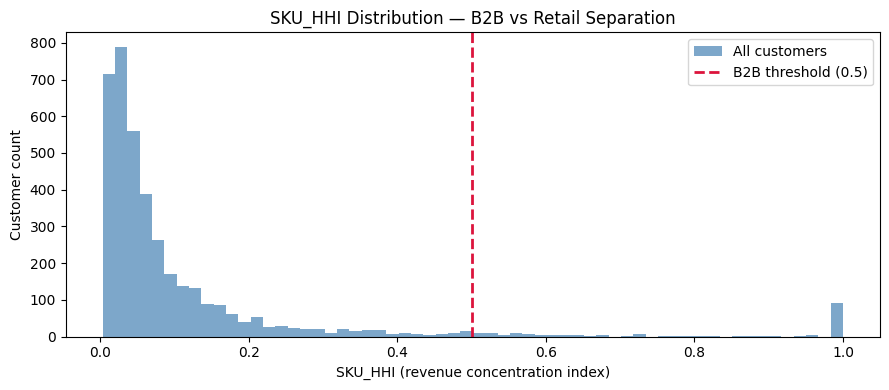

In [9]:
# Apply B2B filter on raw (unscaled) SKU_HHI
raw_df = customer_features.set_index('CustomerID')
B2B_THRESHOLD = 0.5

b2b_mask   = raw_df['SKU_HHI'] > B2B_THRESHOLD
b2b_ids    = raw_df[b2b_mask].index
retail_ids = raw_df[~b2b_mask].index

print(f"Total customers  : {len(raw_df):,}")
print(f"B2B (SKU_HHI > {B2B_THRESHOLD}) : {len(b2b_ids):,}  ({100*len(b2b_ids)/len(raw_df):.1f}%)")
print(f"Retail cohort    : {len(retail_ids):,}  ({100*len(retail_ids)/len(raw_df):.1f}%)")

# Visualise SKU_HHI distribution with threshold
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(raw_df['SKU_HHI'], bins=60, color='steelblue', alpha=0.7, label='All customers')
ax.axvline(B2B_THRESHOLD, color='crimson', lw=2, ls='--', label=f'B2B threshold ({B2B_THRESHOLD})')
ax.set_xlabel('SKU_HHI (revenue concentration index)')
ax.set_ylabel('Customer count')
ax.set_title('SKU_HHI Distribution — B2B vs Retail Separation')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_features/b2b_skuhhi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
b2b_profile   = raw_df.loc[b2b_ids].median()
retail_profile = raw_df.loc[retail_ids].median()
comparison = pd.DataFrame({'B2B median': b2b_profile, 'Retail median': retail_profile})
comparison['ratio'] = (comparison['B2B median'] / comparison['Retail median'].replace(0, np.nan)).round(2)
print("B2B vs Retail feature medians (raw):")
print(comparison.sort_values('ratio', ascending=False).to_string())

B2B vs Retail feature medians (raw):
                      B2B median  Retail median  ratio
SKU_HHI                 1.000000       0.046904  21.32
Recency               146.000000      47.000000   3.11
BulkLineRate            1.000000       0.370079   2.70
QuarterConcentration    1.000000       0.727057   1.38
MonthlyOrderRate        1.000000       1.000000   1.00
AOV                   166.316667     286.716667   0.58
QuantityCV              0.336718       0.869170   0.39
MedianBasketQty        52.000000     150.000000   0.35
PriceCV                 0.062027       0.871132   0.07
RepeatSKUFraction       0.000000       0.063830   0.00
BasketSizeCV            0.000000       0.309891   0.00
InterPurchaseCV         0.000000       0.000000    NaN
ReturnRate              0.000000       0.000000    NaN
SpendAcceleration       0.000000       0.000000    NaN


## 6. Lưu kết quả

In [11]:
# Lưu artefacts vào sandbox (data/_sandbox/). wpath() tự tạo thư mục nếu chưa có.
scaled_path        = wpath('processed/customer_features_scaled.csv')
retail_scaled_path = wpath('processed/customer_features_retail_scaled.csv')
b2b_ids_path       = wpath('processed/b2b_customer_ids.csv')
models_dir         = wpath('models')

# Full population scaled features (3,920 customers, 14 features)
df_scaled.to_csv(scaled_path)

# Retail cohort scaled features (3,741 customers)
df_retail_scaled = df_scaled.loc[retail_ids]
df_retail_scaled.to_csv(retail_scaled_path)

# B2B customer IDs
pd.Series(b2b_ids, name='CustomerID').to_csv(b2b_ids_path, index=False)

# Save pipeline artefacts (quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json)
fe.save_pipeline(models_dir)

print("Saved:")
print(f"  {scaled_path}        — {df_scaled.shape}")
print(f"  {retail_scaled_path} — {df_retail_scaled.shape}")
print(f"  {b2b_ids_path}       — {len(b2b_ids)} rows")
print(f"  {models_dir}/  — quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json")

Saved:
  /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/data/_sandbox/processed/customer_features_scaled.csv        — (3920, 14)
  /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/data/_sandbox/processed/customer_features_retail_scaled.csv — (3741, 14)
  /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/data/_sandbox/processed/b2b_customer_ids.csv       — 179 rows
  /Users/thaihanguyen/Desktop/03_work/99_personal_projects/17_data_science_project/advanced_customer_segmentation/data/_sandbox/models/  — quantile_transformer.pkl, scaler.pkl, pipeline_metadata.json


## Tổng kết

| | Giá trị |
|---|---|
| Giao dịch thô | khoảng 397.884 |
| Khách hàng | 3.920 |
| Đặc trưng ứng viên | 20 (trên 5 nhóm) |
| Đặc trưng giữ lại | 14 (sau bộ lọc tương quan |r|>0,85) |
| Tiền xử lý | QuantileTransformer(normal, 500q), StandardScaler, ±3σ clip |
| Tài khoản B2B (SKU_HHI > 0,5) | 179 (4,6%) |
| Nhóm retail | 3.741 (95,4%) |

**Các file output:**
- `data/processed/customer_features_scaled.csv`: 3.920 x 14 (toàn bộ dân số)
- `data/processed/customer_features_retail_scaled.csv`: 3.741 x 14 (nhóm retail cho phân cụm)
- `data/processed/b2b_customer_ids.csv`